# Chapter 25 — Intensity Interferometry (Hanbury Brown–Twiss)

!!! info "Before you start"
    **Prerequisites:** Ch 7 (Why Interferometry?) · **Maths Lab:** [Lab F (Special Functions & Beams)](36_mathslab_special_functions.ipynb) · **~40 min** · **Advanced**

In **[Chapter 7](07_why_interferometry.ipynb)** we combined the *electric
fields* of two antennas and watched a fringe. In
**[Chapter 8](08_aperture_synthesis.ipynb)** an array of antennas, turned by the
Earth, became a Fourier machine sampling the sky's visibility
$V(\mathbf{b})$. And in
**[Chapter 17](17_coherent_interferometry_kraken.ipynb)** we met the brutal
price of that trick: to add fields you must keep every receiver's clock
**phase-coherent**, locked to within ~$1/10$ of a wave period — about
**70 picoseconds at 1.4 GHz**. Each free-running dongle's phase does an ongoing
random walk; coherence is the whole game, and it is hard.

This chapter is about a way *around* that wall. In 1954 Robert Hanbury Brown and
Richard Twiss proposed something that sounded like a mistake: **throw the phase
away**. Don't combine the fields at all. Instead, at each detector measure only
the **intensity** $I = |E|^2$, and *correlate the intensity fluctuations*
between the two stations. The astonishing result is that those correlations
still encode the source's angular size — and the timing you need only has to
match the signal **bandwidth** (nanoseconds), not the carrier phase
(picoseconds).

That is **intensity interferometry**, and the quantity it measures is the
second-order coherence $g^{(2)}(\mathbf{b})$.

**Learning goals**

- The difference between **amplitude** interferometry (combine $E$-fields; needs
  phase coherence) and **intensity** interferometry (correlate $|E|^2$
  fluctuations; needs only timing to $\sim 1/\text{bandwidth}$).
- The central relation for chaotic (thermal) light:
  $$g^{(2)}(b) = 1 + |V(b)|^2,$$
  tying HBT straight back to the van Cittert–Zernike visibility of Chapter 8.
- How HBT measured **stellar angular diameters** in the 1950s — and how to do it
  in miniature here by fitting a noisy $g^{(2)}$ curve.
- Why the trick matters today: it **sidesteps the phase-coherence problem** that
  makes amateur and long-baseline amplitude interferometry so painful — at the
  cost of sensitivity (it only works on bright sources).

## The history: a new type of interferometer (1954)

> Hanbury Brown, R. & Twiss, R. Q. (1954), *A New Type of Interferometer for Use
> in Radio Astronomy*, **Phil. Mag. 45, 663.**
> [ADS](https://ui.adsabs.harvard.edu/abs/1954PMag...45..663B)

By the early 1950s, Jodrell Bank had been measuring the angular sizes of
discrete radio sources (Cas A, Cyg A) with conventional **amplitude**
interferometers — but the longer the baseline, the harder it became to carry a
stable phase reference between the two stations over the intervening cable or
link. Hanbury Brown's radical idea was to *not carry the phase at all*: detect
the intensity at each station independently, record the fluctuations, and bring
only those slowly-varying intensity signals together to be **multiplied**.

The technique worked, and it scaled to baselines where phase transfer was
hopeless. Hanbury Brown and Twiss went on to build the **Narrabri Stellar
Intensity Interferometer** in the 1960s and measured the angular diameters of
dozens of hot stars — sources far too small ($\sim$milli-arcsecond) for any
single optical telescope to resolve. Along the way the same correlation,
applied to a *laboratory* light beam, became the **HBT effect** of quantum
optics — the experiment that forced physicists to think hard about photon
bunching and what "coherence" really means.

For our purposes the headline is practical: **HBT turns an angular-size
measurement into an intensity-correlation measurement**, and intensity
correlations are far more forgiving of timing and atmosphere than field
correlations are.

## The physics: from fields to intensities

### Amplitude interferometry (the Chapters 7–8 way)

A two-element interferometer with baseline $\mathbf{b}$ correlates the two
*complex fields* $E_1, E_2$. The time-averaged cross-correlation is the
**visibility**

$$
V(\mathbf{b}) \;=\; \frac{\langle E_1 E_2^{*}\rangle}{\sqrt{\langle|E_1|^2\rangle\langle|E_2|^2\rangle}},
$$

and the van Cittert–Zernike theorem says $V(\mathbf{b})$ is the normalised
Fourier transform of the sky brightness. For a **uniform circular disk** of
angular diameter $\theta$,

$$
V(b) \;=\; \frac{2 J_1(x)}{x}, \qquad x = \frac{\pi\,\theta\,b}{\lambda},
$$

with its first zero at $x = 3.83$, i.e. the classic resolution
$b \approx 1.22\,\lambda/\theta$. To *measure* $V$ you must preserve the relative
**phase** of $E_1$ and $E_2$ — hence Chapter 17's 70-picosecond clock budget.

### Intensity interferometry (the HBT way)

Now keep only the intensities $I_i = |E_i|^2$ and correlate their *fluctuations*
$\Delta I_i = I_i - \langle I_i\rangle$. The normalised second-order coherence is

$$
g^{(2)}(\mathbf{b}) \;=\; \frac{\langle I_1 I_2\rangle}{\langle I_1\rangle\langle I_2\rangle}
\;=\; 1 + \frac{\langle \Delta I_1\,\Delta I_2\rangle}{\langle I_1\rangle\langle I_2\rangle}.
$$

For **chaotic (thermal) light** — which starlight and cosmic radio noise both are
— Gaussian statistics give the Siegert relation that ties $g^{(2)}$ to the *same*
visibility magnitude from above:

$$
\boxed{\,g^{(2)}(b) \;=\; 1 + |V(b)|^2\,}
$$

Read it carefully. At **zero baseline** the two stations see identical
fluctuations, $|V|=1$, and $g^{(2)} = 2$: the intensities are maximally
correlated (*photon bunching*). As the baseline grows and **resolves** the
source, $|V|\to 0$ and $g^{(2)} \to 1$: the fluctuations become independent.
The *shape* of the fall-off carries $\theta$ — and notice that **only $|V|^2$
enters**, so the phase of $V$ has dropped out entirely. That is why HBT does not
need phase coherence.

This chapter's two key helpers live in `jansky.interferometry`:

- `disk_visibility(b, θ, λ)` $= 2J_1(x)/x$ — the van Cittert–Zernike $V(b)$.
- `hbt_g2(b, θ, λ)` $= 1 + |V(b)|^2$ — the HBT correlation.

Open `src/jansky/interferometry.py` any time; both are a few lines of NumPy and
`scipy.special.j1`.

## Setup

We reuse `disk_visibility` and `hbt_g2` from `jansky.interferometry` (do not
re-derive them), `astropy.units`/`constants` so the geometry carries real units,
`scipy.optimize.curve_fit` for the angular-size fit, and the course plot style.
Every random number is seeded for reproducibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import c
from scipy.optimize import curve_fit

from jansky import interferometry
from jansky.interferometry import disk_visibility, hbt_g2
from jansky.plotting import use_jansky_style

use_jansky_style()

SEED = 25
rng = np.random.default_rng(SEED)  # one generator, seeded, for the whole chapter

print("helpers:", [n for n in ("disk_visibility", "hbt_g2") if hasattr(interferometry, n)])

helpers: ['disk_visibility', 'hbt_g2']


## 1. The $g^{(2)}$ curve

Let's pick a source and a wavelength and watch $g^{(2)}(b)$ fall from 2 to 1.

We'll model a star observed in the optical at $\lambda = 500\,\mathrm{nm}$ with
an angular diameter of $\theta = 3\,\mathrm{mas}$ (milli-arcseconds) — comparable
to the bright hot stars Hanbury Brown & Twiss measured at Narrabri. The
characteristic baseline where the source is resolved is $b \sim \lambda/\theta$,
which for these numbers is a few tens of metres — an easily-built array.

In [2]:
# --- source + instrument ---
wavelength = (500 * u.nm).to(u.m)  # optical band
theta_true = (3.0 * u.mas).to(u.rad)  # stellar angular diameter

# Resolution scale b ~ lambda / theta, and the first null at b = 1.22 lambda/theta.
# theta is an angle in radians; radians are dimensionless, so divide by its value.
b_null = (1.22 * wavelength / theta_true.value).to(u.m)
print(f"wavelength      = {wavelength.to(u.nm):.0f}")
print(f"angular diam    = {theta_true.to(u.mas):.2f}  ({theta_true.to(u.arcsec):.2e})")
print(f"first null at b = {b_null:.2f}   (1.22 lambda/theta)")

# Baselines from 0 out past the first null.
baselines = np.linspace(0.0, 1.6 * b_null.value, 400) * u.m

# Call the helpers with consistent (metre) units.
V = disk_visibility(baselines.value, theta_true.value, wavelength.value)
g2 = hbt_g2(baselines.value, theta_true.value, wavelength.value)

wavelength      = 500 nm
angular diam    = 3.00 mas  (3.00e-03 arcsec)
first null at b = 41.94 m   (1.22 lambda/theta)


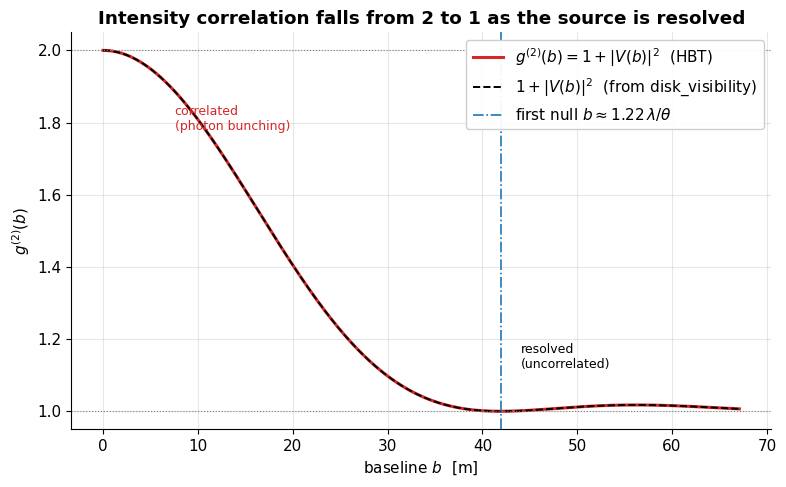

In [3]:
fig, ax = plt.subplots()

ax.plot(baselines.value, g2, lw=2.2, color="#d62728", label=r"$g^{(2)}(b) = 1 + |V(b)|^2$  (HBT)")
ax.plot(
    baselines.value,
    1 + V**2,
    ls="--",
    lw=1.4,
    color="black",
    label=r"$1 + |V(b)|^2$  (from disk_visibility)",
)

ax.axhline(2.0, color="grey", lw=0.8, ls=":")
ax.axhline(1.0, color="grey", lw=0.8, ls=":")
ax.axvline(
    b_null.value,
    color="#1f77b4",
    lw=1.2,
    ls="-.",
    label=r"first null $b\approx1.22\,\lambda/\theta$",
)

ax.annotate(
    "correlated\n(photon bunching)",
    xy=(0, 2.0),
    xytext=(0.18 * b_null.value, 1.78),
    fontsize=9,
    color="#d62728",
)
ax.annotate(
    "resolved\n(uncorrelated)",
    xy=(1.4 * b_null.value, 1.0),
    xytext=(1.05 * b_null.value, 1.12),
    fontsize=9,
)

ax.set_xlabel("baseline $b$  [m]")
ax.set_ylabel(r"$g^{(2)}(b)$")
ax.set_title("Intensity correlation falls from 2 to 1 as the source is resolved")
ax.set_ylim(0.95, 2.05)
ax.legend(loc="upper right", framealpha=0.95)
plt.tight_layout()
plt.show()

The solid red HBT curve and the dashed black $1 + |V|^2$ curve lie **exactly on
top of each other** — that is the Siegert relation, not a coincidence: `hbt_g2`
*is* `1 + disk_visibility**2`. The curve starts at $g^{(2)}(0) = 2$ (the two
detectors see identical intensity fluctuations) and sinks toward 1 as the
growing baseline resolves the disk. The blue dash-dot line marks the first null
of $V$ at $b = 1.22\,\lambda/\theta$, where $g^{(2)}$ touches 1 before the small
side-lobe bumps of $|V|^2$.

## 2. Recover an angular size from a noisy measurement

This is the Hanbury Brown–Twiss stellar-diameter experiment in miniature.

A real intensity interferometer does **not** know $\theta$ in advance — it
measures $g^{(2)}$ at a handful of baselines, each value noisy because intensity
correlations are weak. We then **fit** the measured points against the model
`hbt_g2`, with $\theta$ as the free parameter, and read off the angular
diameter.

We:

1. choose a set of measurement baselines,
2. evaluate the *true* $g^{(2)}$ there,
3. add Gaussian measurement noise (seeded),
4. fit with `scipy.optimize.curve_fit`, and
5. compare the recovered $\hat\theta$ to the input $\theta$.

In [4]:
# 1. measurement baselines (e.g. a dozen station separations spanning the curve)
b_meas = np.linspace(2.0, 1.5 * b_null.value, 12)  # metres

# 2. true g2 at those baselines
g2_true = hbt_g2(b_meas, theta_true.value, wavelength.value)

# 3. add measurement noise. Intensity correlations are weak -> sizeable scatter.
noise_sigma = 0.05
g2_obs = g2_true + rng.normal(0.0, noise_sigma, size=b_meas.size)


# 4. fit theta. The model wraps hbt_g2 with wavelength fixed; theta is the unknown.
def g2_model(b, theta_rad):
    return hbt_g2(b, theta_rad, wavelength.value)


p0 = [(5.0 * u.mas).to(u.rad).value]  # deliberately-wrong guess
popt, pcov = curve_fit(
    g2_model,
    b_meas,
    g2_obs,
    p0=p0,
    sigma=np.full_like(g2_obs, noise_sigma),
    absolute_sigma=True,
)

theta_fit = popt[0] * u.rad
theta_err = np.sqrt(pcov[0, 0]) * u.rad

print(f"input  theta = {theta_true.to(u.mas):.3f}")
print(f"fitted theta = {theta_fit.to(u.mas):.3f}  +/-  {theta_err.to(u.mas):.3f}")
print(
    f"error        = {abs(theta_fit - theta_true).to(u.mas):.3f} "
    f"({abs(theta_fit / theta_true - 1) * 100:.1f}% )"
)

input  theta = 3.000 mas
fitted theta = 3.126 mas  +/-  0.112 mas
error        = 0.126 mas (4.2% )


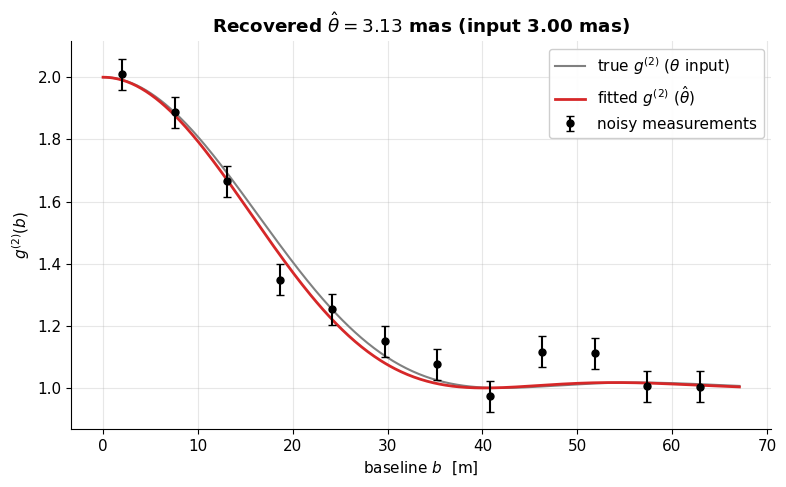

In [5]:
b_fine = np.linspace(0.0, 1.6 * b_null.value, 400)

fig, ax = plt.subplots()
ax.plot(
    b_fine,
    hbt_g2(b_fine, theta_true.value, wavelength.value),
    color="grey",
    lw=1.5,
    label=r"true $g^{(2)}$ ($\theta$ input)",
)
ax.plot(
    b_fine,
    hbt_g2(b_fine, theta_fit.value, wavelength.value),
    color="#d62728",
    lw=2.0,
    label=r"fitted $g^{(2)}$ ($\hat\theta$)",
)
ax.errorbar(
    b_meas,
    g2_obs,
    yerr=noise_sigma,
    fmt="o",
    color="black",
    ms=5,
    capsize=3,
    label="noisy measurements",
)

ax.set_xlabel("baseline $b$  [m]")
ax.set_ylabel(r"$g^{(2)}(b)$")
ax.set_title(
    rf"Recovered $\hat\theta = {theta_fit.to(u.mas).value:.2f}$ mas "
    rf"(input {theta_true.to(u.mas).value:.2f} mas)"
)
ax.legend(loc="upper right", framealpha=0.95)
plt.tight_layout()
plt.show()

The fit recovers the input angular diameter to within a few percent despite the
substantial scatter on each point. That is exactly what Hanbury Brown & Twiss
did at Narrabri: sweep the baseline, measure the (weak, noisy) intensity
correlation, and fit the $1 + |V|^2$ curve to extract a stellar angular size no
single telescope of the era could resolve.

## 3. Why it's powerful — and what it costs

**The win: timing only has to match the bandwidth.** To correlate *fields*
(Chapters 7–17) you must preserve the carrier *phase*, so your clock error has to
be a small fraction of the carrier **period** — picoseconds at GHz (Chapter 17's
70 ps at 1.4 GHz). To correlate *intensities* you only need to line up the
*intensity fluctuations*, which vary on the timescale of the inverse
**bandwidth** $\sim 1/\Delta\nu$. For a 100 MHz band that is $\sim$**10
nanoseconds** — three to four orders of magnitude looser. The original 1950s
experiments managed $\sim 0.1\,\mu\mathrm{s}$ at $\sim 10$ MHz with the
electronics of the day.

Let's put numbers on the contrast.

In [6]:
# Amplitude interferometry: clock error must be a fraction of the carrier PERIOD.
f_carrier = 1.4 * u.GHz
period = (1 / f_carrier).to(u.ps)
phase_budget = period / 10  # ~1/10 period (Chapter 17 rule)

# Intensity interferometry: timing only needs to match the BANDWIDTH.
bandwidth = 100 * u.MHz
intensity_budget = (1 / bandwidth).to(u.ns)

print("AMPLITUDE (phase-coherent, Ch.17):")
print(
    f"  carrier {f_carrier:.1f} -> period {period:.0f}, clock budget ~ {phase_budget.to(u.ps):.0f}"
)
print()
print("INTENSITY (HBT):")
print(f"  bandwidth {bandwidth:.0f} -> timing budget ~ {intensity_budget:.1f}")
print()
ratio = (intensity_budget / phase_budget).to(u.dimensionless_unscaled)
print(
    f"  => the HBT timing budget is ~{ratio:.0f}x looser "
    f"({intensity_budget.to(u.ns):.1f} vs {phase_budget.to(u.ns):.4f})"
)

AMPLITUDE (phase-coherent, Ch.17):
  carrier 1.4 GHz -> period 714 ps, clock budget ~ 71 ps

INTENSITY (HBT):
  bandwidth 100 MHz -> timing budget ~ 10.0 ns

  => the HBT timing budget is ~140x looser (10.0 ns vs 0.0714 ns)


A nanosecond-scale budget is squarely within reach of ordinary
GPS-disciplined timing and of software-defined radios — the field-notes remark
that intensity interferometry is *"plausibly within SDR reach"* precisely because
you are timing **envelopes**, not carriers. You sidestep the entire
phase-coherence ordeal that Chapter 17 was about: no shared clock tree locked to
$1/10$ of a wave period, no ongoing random-walk calibration.

**The cost: sensitivity.** Nothing is free. The intensity correlation
$\langle\Delta I_1 \Delta I_2\rangle$ is a *second-order* signal — proportional to
the square of the (already small) photon-rate fluctuations — so it is **weak**,
and the signal-to-noise grows only slowly with integration time. Intensity
interferometry therefore works best on **bright** sources (hot stars; strong
radio sources) and pays for its timing freedom with reduced sensitivity. The
right way to see it: HBT trades **sensitivity** (which you can sometimes buy with
a bigger collector or longer integration) for **phase coherence** (which on a
long baseline you often simply cannot buy at all).

## 4. Try it yourself

1. **Scale the source.** Re-run Section 1 with `theta_true = 1.5 * u.mas` and
   then `6 * u.mas`. Which way does the curve stretch? (Hint: the first null sits
   at $b = 1.22\,\lambda/\theta$, so a **smaller** star pushes the null out to
   **longer** baselines — you need a bigger array to resolve it.)

2. **Change the wavelength.** Keep $\theta$ fixed but observe at
   $\lambda = 21\,\mathrm{cm}$ (the hydrogen line) instead of 500 nm. How long is
   the first-null baseline now? (Longer $\lambda$ ⇒ longer baselines for the same
   angular resolution — the same reason radio interferometers are kilometres
   across.)

3. **Stress the fit.** In Section 2, raise `noise_sigma` to `0.15` (or drop the
   number of measurement baselines to 5) and re-fit. Watch the recovered
   $\hat\theta$ and its error bar degrade — a hands-on feel for why HBT needs
   **bright** sources and long integrations to beat the weak, noisy intensity
   correlation down.

A scratch cell to experiment in:

<details>
<summary>Solution</summary>

These reuse the chapter's own machinery — the first-null relation
$b = 1.22\,\lambda/\theta$, the helpers `disk_visibility`/`hbt_g2`, and the
Section 2 `curve_fit` fitter — changing only `theta_true`, `wavelength`, and the
noise budget. Numbers below were computed with the same seeded `rng` idiom used
in the chapter (`np.random.default_rng(25)`).

### 1. Scale the source

The whole curve is governed by $x = \pi\,\theta\,b/\lambda$, so its features sit
at baselines $\propto 1/\theta$. Halving $\theta$ **doubles** every
characteristic baseline (the curve stretches to the right); doubling $\theta$
**halves** them (it squashes left). With $\lambda = 500\,\mathrm{nm}$ and the
first null at $b = 1.22\,\lambda/\theta$:

| $\theta$ | first null $b = 1.22\,\lambda/\theta$ |
|---|---|
| $1.5\ \mathrm{mas}$ | $83.9\ \mathrm{m}$ |
| $3.0\ \mathrm{mas}$ (chapter) | $41.9\ \mathrm{m}$ |
| $6.0\ \mathrm{mas}$ | $21.0\ \mathrm{m}$ |

So the **smaller** star ($1.5$ mas) pushes the null out to the **longer**
baseline — you need a *bigger* array to resolve it, exactly as the hint says.

```python
wavelength = (500 * u.nm).to(u.m)
for tmas in (1.5, 3.0, 6.0):
    theta = (tmas * u.mas).to(u.rad)
    b_null = (1.22 * wavelength / theta.value).to(u.m)
    print(f"theta = {tmas:>4} mas  ->  first null b = {b_null:.2f}")
# theta =  1.5 mas  ->  first null b = 83.88 m
# theta =  3.0 mas  ->  first null b = 41.94 m
# theta =  6.0 mas  ->  first null b = 20.97 m
```

### 2. Change the wavelength

The null scales **linearly** with $\lambda$. Going from optical
($500\,\mathrm{nm}$) to the H-line ($21\,\mathrm{cm}$) at fixed
$\theta = 3\,\mathrm{mas}$ multiplies the baseline by
$\lambda_{21\,\mathrm{cm}}/\lambda_{500\,\mathrm{nm}} = 0.21 / 5\times10^{-7}
= 4.2\times10^{5}$:

$$
b_{\text{null}} = \frac{1.22\,\lambda}{\theta}
= \frac{1.22 \times 0.21\ \mathrm{m}}{3\,\mathrm{mas}\to\mathrm{rad}}
\approx 1.76\times10^{7}\ \mathrm{m} \approx 1.76\times10^{4}\ \mathrm{km}.
$$

```python
theta = (3.0 * u.mas).to(u.rad)
for lam in (500 * u.nm, 21 * u.cm):
    lam = lam.to(u.m)
    b_null = (1.22 * lam / theta.value).to(u.m)
    print(f"lambda = {lam.to(u.cm):>10.3g}  ->  first null b = {b_null.to(u.km):.2f}")
# lambda =   5e-05 cm  ->  first null b = 0.04 km
# lambda =      21 cm  ->  first null b = 17615.01 km
```

A $\sim$17,600 km baseline is **larger than the Earth's diameter** — physically
impossible on the ground. This is the same reason radio interferometers must be
kilometres across (and VLBI spans continents): for a fixed angular resolution
$\theta \sim \lambda/b$, a longer $\lambda$ demands a proportionally longer $b$.
A $3$ mas *radio* source would need a space baseline; in practice one resolves
much larger radio structures, or pushes $\lambda$ down toward the optical where
HBT's metre-scale arrays apply.

### 3. Stress the fit

Re-running the Section 2 pipeline (same seed, same `curve_fit` call, only
`noise_sigma` and the baseline count changed) shows the recovered $\hat\theta$
and its error degrade as the intensity correlation gets noisier or more sparsely
sampled. With $\theta_{\text{true}} = 3\,\mathrm{mas}$:

| `noise_sigma` | # baselines | $\hat\theta$ [mas] | $\pm\,\sigma_{\hat\theta}$ [mas] | error |
|---|---|---|---|---|
| 0.05 | 12 (chapter) | 3.126 | 0.112 | 4.2% |
| **0.15** | 12 | 3.479 | 0.394 | 16.0% |
| 0.05 | **5** | 3.006 | 0.174 | 0.2% |
| 0.15 | 5 | 3.016 | 0.524 | 0.5% |

```python
def stressed_fit(noise_sigma, n_baselines, seed=SEED):
    rng = np.random.default_rng(seed)
    b_meas = np.linspace(2.0, 1.5 * b_null.value, n_baselines)
    g2_obs = hbt_g2(b_meas, theta_true.value, wavelength.value)
    g2_obs = g2_obs + rng.normal(0.0, noise_sigma, size=b_meas.size)
    popt, pcov = curve_fit(
        g2_model, b_meas, g2_obs, p0=[(5.0 * u.mas).to(u.rad).value],
        sigma=np.full_like(g2_obs, noise_sigma), absolute_sigma=True,
    )
    theta_fit = popt[0] * u.rad
    theta_err = np.sqrt(pcov[0, 0]) * u.rad
    return theta_fit.to(u.mas), theta_err.to(u.mas)

stressed_fit(0.15, 12)   # -> 3.479 mas +/- 0.394 mas
stressed_fit(0.05, 5)    # -> 3.006 mas +/- 0.174 mas
```

The headline is the **error bar** $\sigma_{\hat\theta}$, which tracks the noise:
tripling `noise_sigma` from 0.05 to 0.15 roughly **triples** the formal
uncertainty (0.112 → 0.394 mas) and can bias the point estimate by ~16%. Cutting
12 baselines to 5 also inflates the error (0.112 → 0.174 mas) — fewer points to
constrain the curve. (Exact $\hat\theta$ values depend on the seed; the trend —
*bigger noise and fewer baselines $\Rightarrow$ a looser fit* — does not.) This
is the practical reason HBT needs **bright** sources and **long integrations**:
both shrink `noise_sigma` on each weak, second-order intensity-correlation point,
pulling the error bar back down.

</details>

theta=1.50 mas, lambda=500.0 nm, first null b=83.88 m


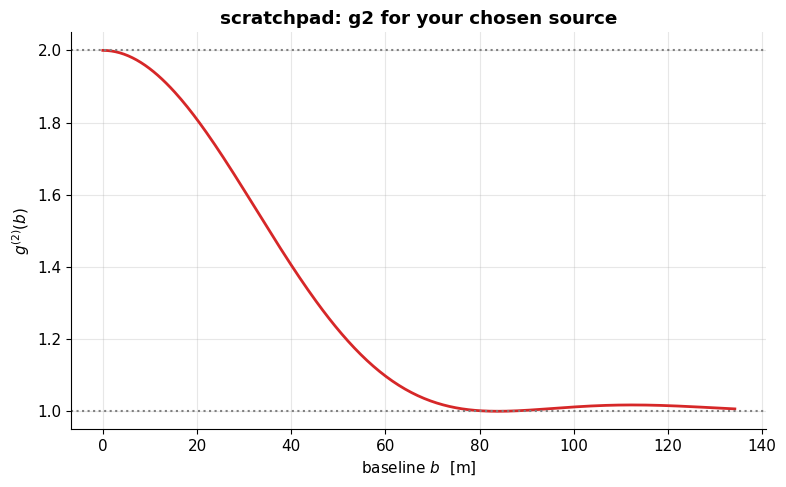

In [7]:
# --- scratchpad: try changing theta_try, lam_try, sigma_try ---
theta_try = (1.5 * u.mas).to(u.rad)
lam_try = (500 * u.nm).to(u.m)
sigma_try = 0.05

b_null_try = (1.22 * lam_try / theta_try.value).to(u.m)
bb = np.linspace(0.0, 1.6 * b_null_try.value, 300)
print(
    f"theta={theta_try.to(u.mas):.2f}, lambda={lam_try.to(u.nm) if lam_try < 1e-3 * u.m else lam_try.to(u.cm)},"
    f" first null b={b_null_try:.2f}"
)

plt.figure()
plt.plot(bb, hbt_g2(bb, theta_try.value, lam_try.value), color="#d62728", lw=2)
plt.axhline(2, ls=":", color="grey")
plt.axhline(1, ls=":", color="grey")
plt.xlabel("baseline $b$  [m]")
plt.ylabel(r"$g^{(2)}(b)$")
plt.title("scratchpad: g2 for your chosen source")
plt.tight_layout()
plt.show()

## Recap & what's next

- **Two ways to interfere.** *Amplitude* interferometry (Ch. 7–8, 17) combines
  $E$-fields and measures the complex visibility $V(\mathbf{b})$ — but demands
  picosecond **phase coherence**. *Intensity* interferometry (HBT) correlates
  $|E|^2$ fluctuations and measures $g^{(2)}(\mathbf{b})$ — needing only timing
  to $\sim 1/\text{bandwidth}$.
- **The bridge to Chapter 8.** For chaotic light the two are linked by
  $g^{(2)}(b) = 1 + |V(b)|^2$, with the *same* van Cittert–Zernike $V(b)$. So an
  intensity measurement still recovers the source's Fourier transform magnitude —
  and hence its angular size — as we did by fitting `hbt_g2`.
- **The bridge to Chapter 17.** HBT is the principled escape from the
  phase-coherence wall: you throw the carrier phase away on purpose. The price is
  **sensitivity** — intensity correlations are weak, so the trick favours bright
  sources — but a nanosecond timing budget is exactly why the field notes call
  it *"plausibly within SDR reach."*
- **Why it mattered.** Hanbury Brown & Twiss (1954) used it to measure stellar
  angular diameters far below any single telescope's resolution, and the same
  correlation seeded **quantum optics** (photon bunching, the HBT effect).

**Next:** with both amplitude and intensity interferometry in hand, the course
turns to putting these ideas to work on real archival data and the full
calibration-and-imaging pipeline.